# Fase 02 — Protocolo de evaluación y modelos base (*baselines*)

**¿Qué hace este cuaderno?** Antes de probar modelos de Machine Learning y Deep Learning más sofisticados
(fases 3 a 6), corremos métodos simples y clásicos como piso de comparación. Si más adelante un modelo
complejo no le gana a estos baselines, esa complejidad no se justifica — es una de las conclusiones más
importantes que puede dar este TP.

**Cómo leer los números.** Vamos a usar cuatro métricas de error (todas: más chico es mejor):

- **MAE**: error promedio, en las mismas unidades que la serie (solicitudes por hora). Fácil de
  interpretar pero no compara bien entre ALB y store_service porque tienen escalas distintas.
- **RMSE**: parecido a MAE, pero penaliza más los errores grandes.
- **MAPE**: error como porcentaje del valor real. Al ser un porcentaje, sí compara bien entre series
  de escalas distintas.
- **MASE**: compara el error del modelo contra el error de repetir, ingenuamente, el valor de hace 24
  horas (la estacionalidad diaria). **MASE < 1 significa que el modelo le gana a esa referencia ingenua;
  MASE > 1 significa que pierde contra ella.** Es la métrica más dura de las cuatro.

Las dos series son `alb` (tráfico total que pasa por el balanceador de carga) y `store_service` (tráfico
por *target*, normalizado por la cantidad de instancias activas — puede moverse por motivos distintos a
un cambio real de tráfico, ver `status/01-data-eda.md`).

In [1]:
import sys
import time
import warnings
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import seaborn as sns

from tsa_final.data import SERIES_REGISTRY, load_clean, INTERVENTION_START, INTERVENTION_END, TEST_START, TEST_END
from tsa_final import evaluation as ev
from tsa_final import baselines as bl

sns.set_theme(style="whitegrid")

SERIES_NAMES = list(SERIES_REGISTRY.keys())
SERIES_LABELS = {"alb": "ALB — tráfico total (RequestCount)", "store_service": "store-service — tráfico por target (RequestCountPerTarget)"}

RESULTS_DIR = Path.cwd().parent / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR = Path.cwd().parent / "informe" / "figuras"
FIG_DIR.mkdir(parents=True, exist_ok=True)


def es_thousands(ax, axis="y"):
    formatter = mticker.FuncFormatter(lambda x, _: f"{x:,.0f}".replace(",", "."))
    if axis == "y":
        ax.yaxis.set_major_formatter(formatter)
    else:
        ax.xaxis.set_major_formatter(formatter)


def savefig(fig, name):
    path = FIG_DIR / f"02_{name}.png"
    fig.savefig(path, dpi=200, bbox_inches="tight")
    print(f"Figura guardada: {path.relative_to(Path.cwd().parent)}")


series = {name: load_clean(name) for name in SERIES_NAMES}
{name: len(s) for name, s in series.items()}

{'alb': 2063, 'store_service': 2063}

## 1. El plan: qué parte de los datos usamos para qué

No hacemos validación cruzada con múltiples ventanas (*backtesting* expansivo): con ~15 modelos
planeados entre las fases 3 a 6, varios de ellos lentos de entrenar (redes neuronales, AutoML), repetir
el ajuste por cada ventana podía llevar el tiempo total a varias horas. En cambio usamos **un solo corte**,
igual de válido para comparar modelos y mucho más rápido:

- **Entrenamiento** (celeste): todo el historial disponible, salvo las dos ventanas de abajo.
- **Validación** (naranja, 48 h): se usa para elegir qué modelo es mejor. Termina justo antes de la
  intervención de despliegue conocida (`INTERVENTION_START`), para no evaluar contra ese evento puntual.
- **Test** (verde, 105 h): se reserva y no se mira hasta el final — es la ventana que va a la tabla
  comparativa definitiva de la fase 6.

Figura guardada: informe/figuras/02_split_train_val_test.png


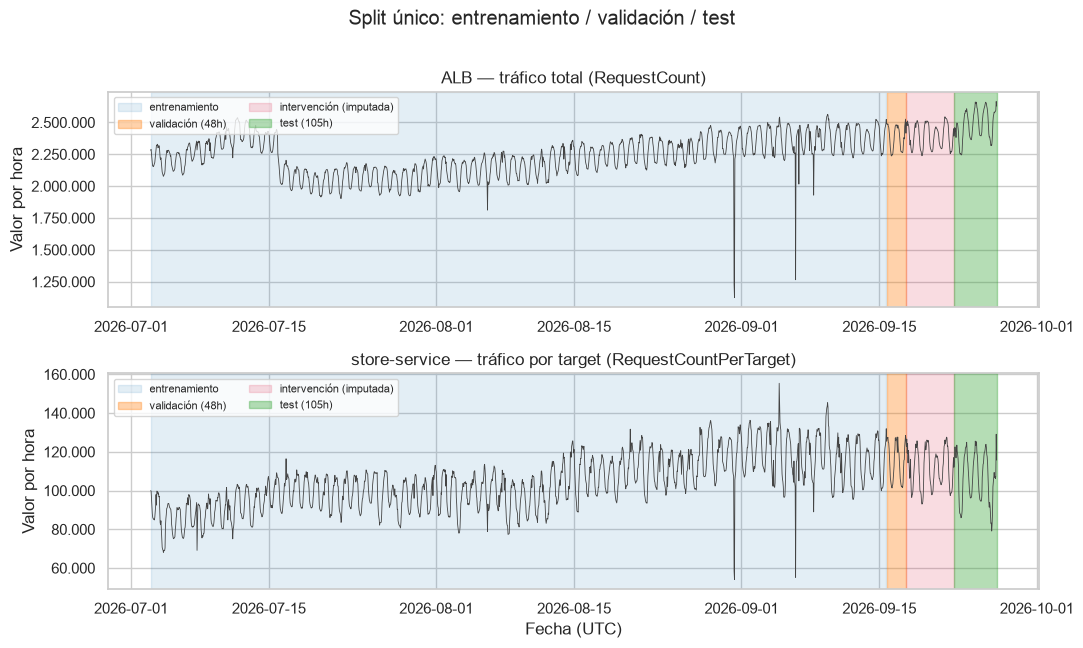

In [2]:
fig, axes = plt.subplots(len(SERIES_NAMES), 1, figsize=(11, 3.2 * len(SERIES_NAMES)), sharex=False)
for ax, name in zip(axes, SERIES_NAMES):
    s = series[name]
    train, val, test = ev.split(s)
    ax.plot(s.index, s.values, linewidth=0.6, color="#444444")
    ax.axvspan(train.index.min(), train.index.max(), color="#1f77b4", alpha=0.12, label="entrenamiento")
    ax.axvspan(val.index.min(), val.index.max(), color="#ff7f0e", alpha=0.35, label="validación (48h)")
    ax.axvspan(INTERVENTION_START, INTERVENTION_END, color="crimson", alpha=0.15, label="intervención (imputada)")
    ax.axvspan(test.index.min(), test.index.max(), color="#2ca02c", alpha=0.35, label="test (105h)")
    ax.set_title(SERIES_LABELS[name])
    ax.set_ylabel("Valor por hora")
    es_thousands(ax)
    ax.legend(loc="upper left", fontsize=8, ncol=2)
axes[-1].set_xlabel("Fecha (UTC)")
fig.suptitle("Split único: entrenamiento / validación / test", y=1.01)
fig.tight_layout()
savefig(fig, "split_train_val_test")
plt.show()

## 2. Los modelos más simples posibles (familia *naive*)

Cuatro formas de pronosticar sin ningún modelo estadístico real: repetir el último valor (`naive`),
repetir el valor de hace 24 horas (`seasonal_naive_m24` — el más razonable de los cuatro, dado que la
fase 01 encontró un ciclo diario fuerte), extrapolar una recta (`drift`), o usar el promedio histórico
(`average`). Son instantáneos de calcular; sirven de piso y de vara de comparación (MASE).

In [3]:
results = ev.ResultsTable()

for series_name in SERIES_NAMES:
    for model_name, fit_fn in bl.NAIVE_MODELS.items():
        ev.evaluate(fit_fn, model=model_name, family="naive", series_name=series_name,
                    series=series[series_name], table=results)

results.to_frame().round(3)

,model,family,series,split,MAE,RMSE,MAPE_%,MASE,fit_time_s
0,naive,naive,alb,val,140474.229,167933.273,6.055,3.548,0.0
1,naive,naive,alb,test,103514.694,120201.682,4.143,2.615,0.0
2,seasonal_naive_m24,naive,alb,val,19369.021,26930.145,0.803,0.489,0.0
3,seasonal_naive_m24,naive,alb,test,78784.340,89398.560,3.150,1.990,0.0
4,drift,naive,alb,val,143670.973,170774.175,6.190,3.629,0.0
5,drift,naive,alb,test,102288.705,118167.899,4.101,2.584,0.0
6,average,naive,alb,val,149950.947,176014.300,6.151,3.788,0.0
7,average,naive,alb,test,237950.597,264377.739,9.381,6.011,0.0
8,naive,naive,store_service,val,16585.832,19226.287,15.210,3.490,0.0
9,naive,naive,store_service,test,12080.818,15721.957,12.520,2.542,0.0


## 3. Refit de las especificaciones SARIMA de TP1

Se reutilizan, sin cambios, las especificaciones que ya se habían elegido en TP1: `SARIMA(1,1,1)x(1,1,1,24)`
para ALB, y para store_service la especificación de POS API de TP1 (`SARIMA(1,1,1)x(1,0,1,24)`, ya que
TP1 no tiene un modelo propio de store_service). Lo único que cambia es que se reentrenan sobre los datos
nuevos de TP Final.

In [4]:
for series_name in SERIES_NAMES:
    order, seasonal_order = bl.SARIMA_SPECS[series_name]
    fit_fn = bl.make_sarima_fit(order, seasonal_order)
    t0 = time.perf_counter()
    ev.evaluate(fit_fn, model=f"SARIMA{order}x{seasonal_order}", family="SARIMA (TP1 refit)",
                series_name=series_name, series=series[series_name], table=results)
    print(f"{series_name}: {time.perf_counter() - t0:.1f}s")

results.to_frame().tail(4).round(3)

alb: 5.5s


store_service: 4.2s


,model,family,series,split,MAE,RMSE,MAPE_%,MASE,fit_time_s
16,"SARIMA(1, 1, 1)x(1, 1, 1, 24)",SARIMA (TP1 refit),alb,val,36524.568,41805.967,1.541,0.923,2.635
17,"SARIMA(1, 1, 1)x(1, 1, 1, 24)",SARIMA (TP1 refit),alb,test,60429.073,67638.150,2.419,1.526,2.838
18,"SARIMA(1, 1, 1)x(1, 0, 1, 24)",SARIMA (TP1 refit),store_service,val,3075.429,3597.389,2.761,0.647,1.494
19,"SARIMA(1, 1, 1)x(1, 0, 1, 24)",SARIMA (TP1 refit),store_service,test,6775.498,9003.693,6.978,1.426,2.731


## 4. Extras clásicos: Holt-Winters, MSTL+ARIMA, AutoARIMA

Tres modelos clásicos algo más sofisticados que la familia naive. Holt-Winters y MSTL+ARIMA (que ya
descompone la serie en tendencia + estacionalidad diaria y semanal) son rápidos. `AutoARIMA` — que busca
automáticamente el mejor orden SARIMA — es, con diferencia, el paso más lento de toda la fase 2: entre
45 y 100 segundos por ajuste. Sigue estando lejísimos de las horas que se quieren evitar, pero vale la
pena verlo medido.

In [5]:
for series_name in SERIES_NAMES:
    for model_name in ["holt_winters", "mstl_arima", "auto_arima"]:
        fit_fn = bl.CLASSICAL_MODELS[model_name]
        t0 = time.perf_counter()
        ev.evaluate(fit_fn, model=model_name, family="classical", series_name=series_name,
                    series=series[series_name], table=results)
        print(f"{series_name}/{model_name}: {time.perf_counter() - t0:.1f}s")

results.to_frame().tail(12).round(3)

alb/holt_winters: 0.3s


alb/mstl_arima: 0.9s


alb/auto_arima: 176.5s


store_service/holt_winters: 0.4s


store_service/mstl_arima: 1.0s


store_service/auto_arima: 125.6s


,model,family,series,split,MAE,RMSE,MAPE_%,MASE,fit_time_s
20,holt_winters,classical,alb,val,31604.808,37185.054,1.347,0.798,0.153
21,holt_winters,classical,alb,test,82913.560,92997.970,3.295,2.094,0.175
22,mstl_arima,classical,alb,val,23468.835,28937.842,0.985,0.593,0.469
23,mstl_arima,classical,alb,test,76674.567,84871.261,3.056,1.937,0.441
24,auto_arima,classical,alb,val,18807.501,25924.316,0.796,0.475,97.518
25,auto_arima,classical,alb,test,81488.752,90358.560,3.245,2.058,78.929
26,holt_winters,classical,store_service,val,6840.690,7281.716,6.122,1.439,0.233
27,holt_winters,classical,store_service,test,7910.618,10036.019,8.074,1.665,0.163
28,mstl_arima,classical,store_service,val,3116.579,3593.585,2.731,0.656,0.467
29,mstl_arima,classical,store_service,test,6738.212,8292.037,6.727,1.418,0.509


## 5. ¿Quién gana? Tabla y gráfico comparativo

La tabla completa (una fila por modelo, serie y split) se guarda en `results/02_baselines.csv` para que
las fases siguientes la reutilicen sin volver a correr estos modelos. El gráfico de abajo muestra el
error de validación (MAPE, en %) de cada modelo — **la barra punteada marca `seasonal_naive_m24`**, el
piso a superar. Un modelo a la derecha de esa línea no está justificando su complejidad.

In [6]:
results_df = results.to_frame()
results_df.to_csv(RESULTS_DIR / "02_baselines.csv", index=False)

val_table = results_df[results_df["split"] == "val"].sort_values(["series", "MAE"])
test_table = results_df[results_df["split"] == "test"].sort_values(["series", "MAE"])

print("Ranking en validación (ordenado por MAE, criterio principal de selección):")
val_table.round(3)

Ranking en validación (ordenado por MAE, criterio principal de selección):


,model,family,series,split,MAE,RMSE,MAPE_%,MASE,fit_time_s
24,auto_arima,classical,alb,val,18807.501,25924.316,0.796,0.475,97.518
2,seasonal_naive_m24,naive,alb,val,19369.021,26930.145,0.803,0.489,0.000
22,mstl_arima,classical,alb,val,23468.835,28937.842,0.985,0.593,0.469
20,holt_winters,classical,alb,val,31604.808,37185.054,1.347,0.798,0.153
16,"SARIMA(1, 1, 1)x(1, 1, 1, 24)",SARIMA (TP1 refit),alb,val,36524.568,41805.967,1.541,0.923,2.635
0,naive,naive,alb,val,140474.229,167933.273,6.055,3.548,0.000
4,drift,naive,alb,val,143670.973,170774.175,6.190,3.629,0.000
6,average,naive,alb,val,149950.947,176014.300,6.151,3.788,0.000
10,seasonal_naive_m24,naive,store_service,val,2281.852,3009.786,1.937,0.480,0.000
30,auto_arima,classical,store_service,val,2525.881,2976.936,2.202,0.532,79.468


Figura guardada: informe/figuras/02_val_mape_ranking.png


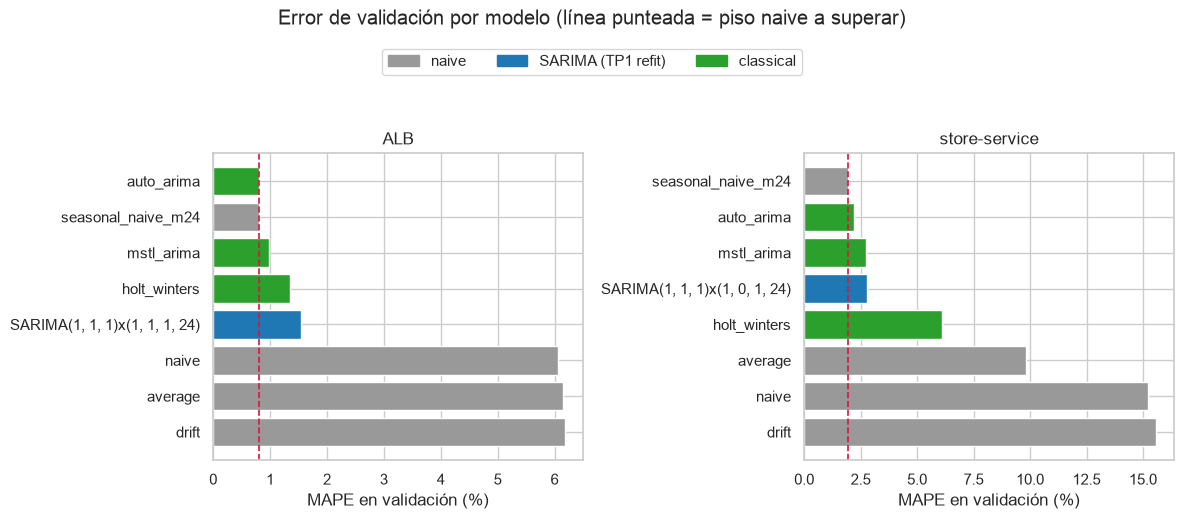

In [7]:
fig, axes = plt.subplots(1, len(SERIES_NAMES), figsize=(12, 4.5))
palette = {"naive": "#999999", "SARIMA (TP1 refit)": "#1f77b4", "classical": "#2ca02c"}
for ax, series_name in zip(axes, SERIES_NAMES):
    sub = val_table[val_table["series"] == series_name].sort_values("MAPE_%", ascending=True)
    colors = [palette[f] for f in sub["family"]]
    ax.barh(sub["model"], sub["MAPE_%"], color=colors)
    naive_mape = sub.loc[sub["model"] == "seasonal_naive_m24", "MAPE_%"].iloc[0]
    ax.axvline(naive_mape, color="crimson", linestyle="--", linewidth=1.2)
    ax.set_title(SERIES_LABELS[series_name].split(" — ")[0])
    ax.set_xlabel("MAPE en validación (%)")
    ax.invert_yaxis()
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in palette.values()]
fig.legend(handles, palette.keys(), loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.08))
fig.suptitle("Error de validación por modelo (línea punteada = piso naive a superar)", y=1.15)
fig.tight_layout()
savefig(fig, "val_mape_ranking")
plt.show()

## 6. La prueba: pronóstico contra lo que realmente pasó (test)

El gráfico anterior elige por validación; este es el control de realidad sobre la ventana de test
(105 h, nunca antes vista por ningún modelo en esta comparación) para el modelo que ganó en validación
en cada serie.

Figura guardada: informe/figuras/02_test_forecast_winners.png


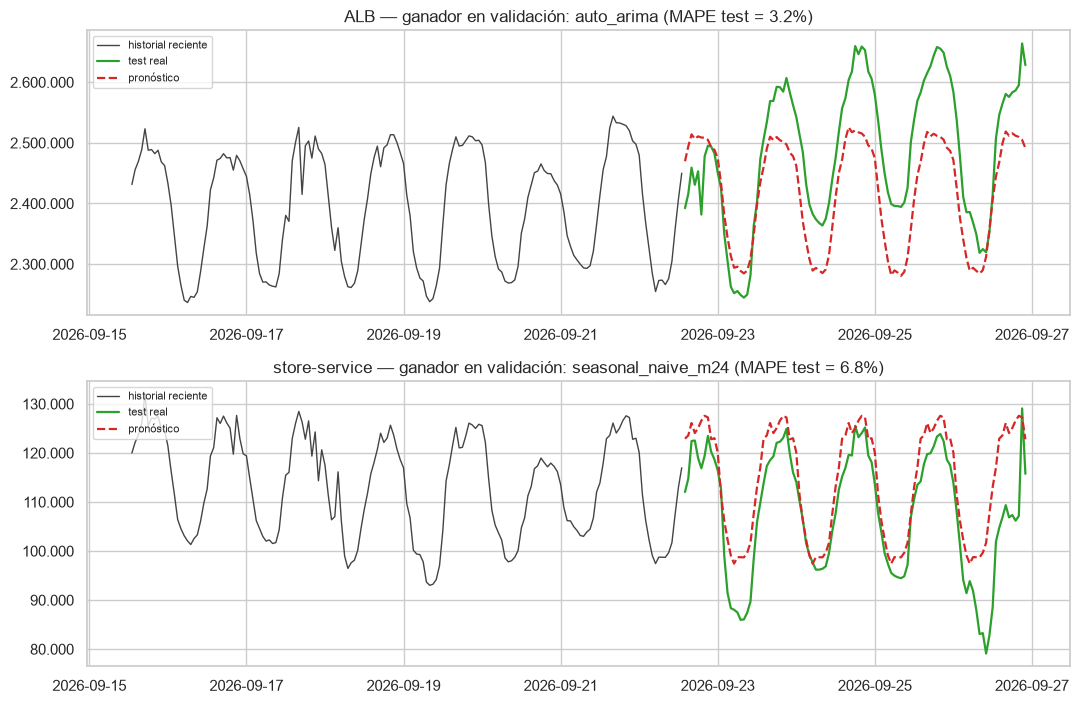

In [8]:
ALL_FITS = dict(bl.NAIVE_MODELS)
ALL_FITS.update(bl.CLASSICAL_MODELS)


def fit_fn_for(model_name, series_name):
    if model_name in ALL_FITS:
        return ALL_FITS[model_name]
    order, seasonal_order = bl.SARIMA_SPECS[series_name]
    return bl.make_sarima_fit(order, seasonal_order)


fig, axes = plt.subplots(len(SERIES_NAMES), 1, figsize=(11, 3.6 * len(SERIES_NAMES)))
winners = {}
for ax, series_name in zip(axes, SERIES_NAMES):
    best_model = val_table[val_table["series"] == series_name].iloc[0]["model"]
    winners[series_name] = best_model

    s = series[series_name]
    train, val, test = ev.split(s)
    fit_data = ev.train_and_val(s)
    predictor = fit_fn_for(best_model, series_name)(fit_data)
    test_pred = predictor(len(test))

    recent = s.loc[fit_data.index.max() - pd.Timedelta(hours=24 * 7):fit_data.index.max()]
    ax.plot(recent.index, recent.values, color="#444444", linewidth=1, label="historial reciente")
    ax.plot(test.index, test.values, color="#2ca02c", linewidth=1.6, label="test real")
    ax.plot(test.index, test_pred, color="#d62728", linewidth=1.6, linestyle="--", label="pronóstico")
    test_mape = results_df[(results_df.model == best_model) & (results_df.series == series_name) &
                            (results_df.split == "test")]["MAPE_%"].iloc[0]
    ax.set_title(f"{SERIES_LABELS[series_name].split(' — ')[0]} — ganador en validación: {best_model} (MAPE test = {test_mape:.1f}%)")
    es_thousands(ax)
    ax.legend(loc="upper left", fontsize=8)
fig.tight_layout()
savefig(fig, "test_forecast_winners")
plt.show()

## 7. Resumen en palabras simples

In [9]:
for series_name in SERIES_NAMES:
    val_best = val_table[val_table["series"] == series_name].iloc[0]
    test_best = test_table[test_table["series"] == series_name].iloc[0]
    naive_val = val_table[(val_table.series == series_name) & (val_table.model == "seasonal_naive_m24")].iloc[0]
    beats_naive = "sí" if val_best["MASE"] < 1 else "no"
    same_winner = "sí" if val_best["model"] == test_best["model"] else "no, cambia"
    print(f"— {series_name}: el mejor modelo en validación es '{val_best['model']}' ({val_best['family']}), "
          f"con MAPE={val_best['MAPE_%']:.1f}% y MASE={val_best['MASE']:.2f} "
          f"(¿le gana al pronóstico ingenuo de ayer? {beats_naive}).")
    print(f"  En test, el mejor pasa a ser '{test_best['model']}' ({'el mismo' if same_winner=='sí' else 'cambia'}). "
          f"El naive estacional por sí solo llega a MAPE={naive_val['MAPE_%']:.1f}% en validación — "
          f"referencia de cuánto cuesta superarlo.")
    print()

— alb: el mejor modelo en validación es 'auto_arima' (classical), con MAPE=0.8% y MASE=0.48 (¿le gana al pronóstico ingenuo de ayer? sí).
  En test, el mejor pasa a ser 'SARIMA(1, 1, 1)x(1, 1, 1, 24)' (cambia). El naive estacional por sí solo llega a MAPE=0.8% en validación — referencia de cuánto cuesta superarlo.

— store_service: el mejor modelo en validación es 'seasonal_naive_m24' (naive), con MAPE=1.9% y MASE=0.48 (¿le gana al pronóstico ingenuo de ayer? sí).
  En test, el mejor pasa a ser 'auto_arima' (cambia). El naive estacional por sí solo llega a MAPE=1.9% en validación — referencia de cuánto cuesta superarlo.



*(Para el informe — sección Análisis de Resultados: completar a mano, tras leer los números de arriba,
si el ganador en validación se sostiene en test o cambia, y qué tan cerca queda `seasonal_naive_m24` de
los modelos más sofisticados. Ese cambio de ranking entre validación y test, si ocurre, es evidencia
legítima del riesgo aceptado al elegir un split único en vez de backtesting — no es un error a esconder.)

## Verificación de integridad

In [10]:
expected_models = len(bl.NAIVE_MODELS) + 1 + len(bl.CLASSICAL_MODELS)  # naive family + SARIMA refit + classical
expected_rows = expected_models * len(SERIES_NAMES) * 2  # x2 splits (val, test)

assert len(results_df) == expected_rows, f"esperaba {expected_rows} filas, hay {len(results_df)}"
assert results_df.duplicated(subset=["model", "family", "series", "split"]).sum() == 0, "hay filas duplicadas"
assert results_df[["MAE", "RMSE", "MAPE_%", "MASE", "fit_time_s"]].isna().sum().sum() == 0, "hay métricas NaN"

print(f"OK: {len(results_df)} filas, sin duplicados, sin NaN. Tiempo total de fit: {results_df['fit_time_s'].sum():.1f}s")

OK: 32 filas, sin duplicados, sin NaN. Tiempo total de fit: 314.3s
